In [14]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUTS_XLSX = "COVID_SQL_outputs1.xlsx"
CHART_DIR    = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})
BLUE, ORANGE, GREY = "#1f77b4", "#e4572e", "#9aa5b1"
SOURCE = "Source: Our World in Data (data to 30 April 2021)"

def finish(fig, ax, title, filename, xlabel=None, ylabel=None):
    ax.set_title(title, loc="left", fontweight="bold")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    fig.text(0.01, 0.005, SOURCE, fontsize=7, color="gray")
    fig.text(0.99, 0.005, "Graphic by Stuart Morrison", fontsize=7, color="gray", ha="right")
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(CHART_DIR / filename)
    plt.show()

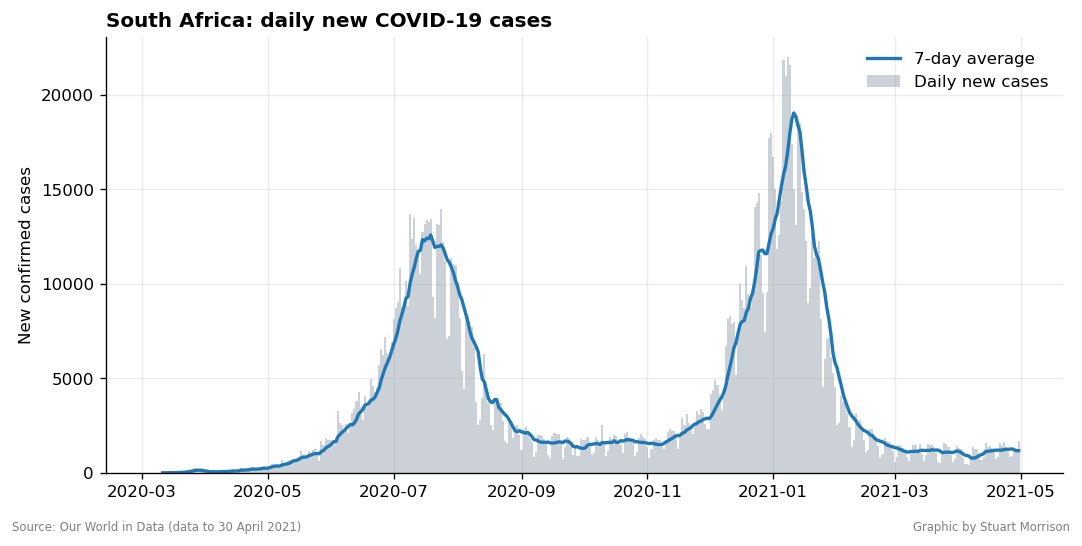

In [15]:
#Chart 1: South Africa daily new cases + 7-day average (Q5)

q5 = pd.read_excel(OUTPUTS_XLSX, sheet_name="Q5", parse_dates=["date"])
q5["new_cases_7d"] = q5["new_cases"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(q5["date"], q5["new_cases"], width=1, color=GREY, alpha=0.5, label="Daily new cases")
ax.plot(q5["date"], q5["new_cases_7d"], color=BLUE, linewidth=2, label="7-day average")
ax.legend(frameon=False)
finish(fig, ax, "South Africa: daily new COVID-19 cases", "01_south_africa_new_cases.png",
       ylabel="New confirmed cases")

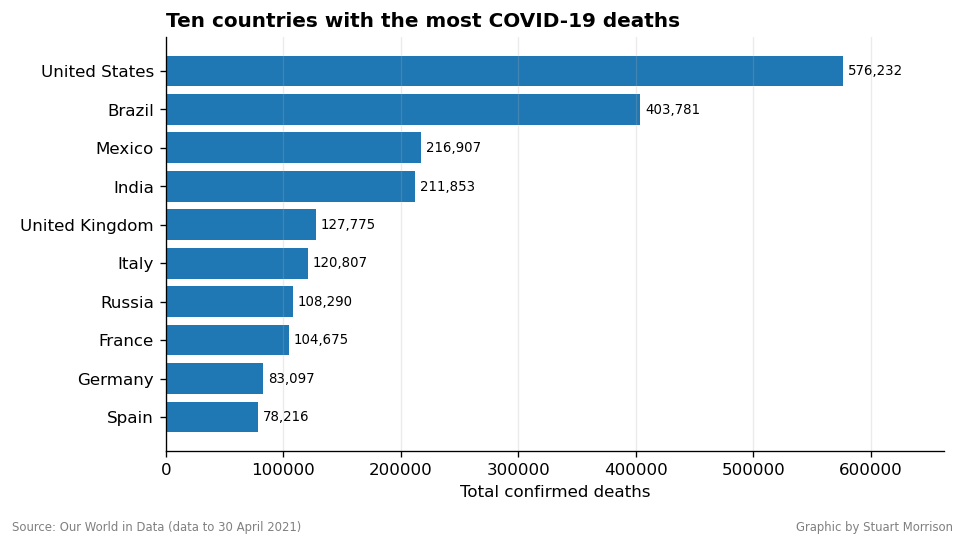

In [16]:
#Chart 2: Top 10 countries by total deaths (Q2)
q2 = pd.read_excel(OUTPUTS_XLSX, sheet_name="Q2").sort_values("highest_total_deaths")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(q2["location"], q2["highest_total_deaths"], color=BLUE)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in q2["highest_total_deaths"]], padding=3, fontsize=8)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, q2["highest_total_deaths"].max() * 1.15)
finish(fig, ax, "Ten countries with the most COVID-19 deaths", "02_top10_total_deaths.png",
       xlabel="Total confirmed deaths")

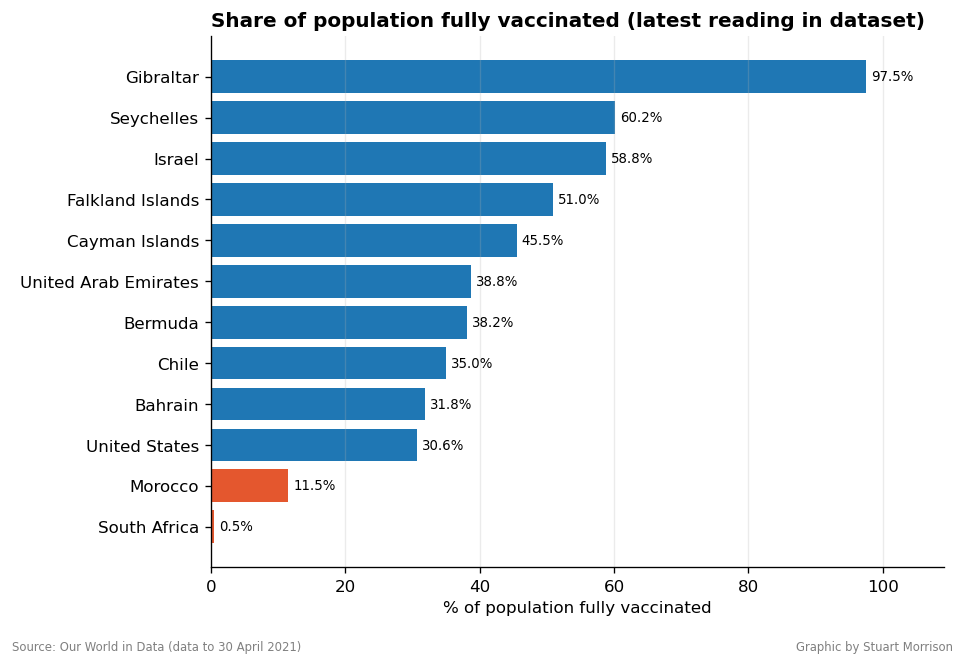

In [17]:
#Chart 3: % fully vaccinated, top 10 + selected African countries (Q11) -
q11 = pd.read_excel(OUTPUTS_XLSX, sheet_name="Q11")
AFRICA_PICKS = ["South Africa", "Nigeria", "Kenya", "Morocco"]
top = q11.nlargest(10, "pct_fully_vaccinated")
picks = q11[q11["location"].isin(AFRICA_PICKS)]
plot = pd.concat([top, picks]).drop_duplicates("location").sort_values("pct_fully_vaccinated")
colors = [ORANGE if loc in AFRICA_PICKS else BLUE for loc in plot["location"]]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(plot["location"], plot["pct_fully_vaccinated"], color=colors)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in plot["pct_fully_vaccinated"]], padding=3, fontsize=8)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, plot["pct_fully_vaccinated"].max() * 1.12)
finish(fig, ax, "Share of population fully vaccinated (latest reading in dataset)",
       "03_pct_fully_vaccinated.png", xlabel="% of population fully vaccinated")

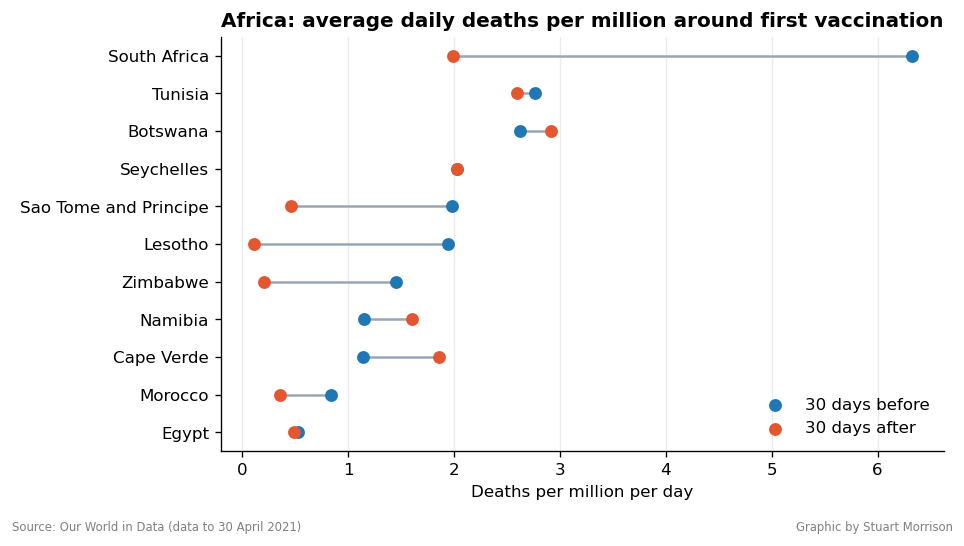

Charts saved to C:\Users\stuar\OneDrive\Documents\GitHub\COVID-SQL-project\charts


In [18]:
#Chart 4: Deaths per million before vs after first vaccination (Q12)
q12 = pd.read_excel(OUTPUTS_XLSX, sheet_name="Q12").dropna(subset=["before_deaths_per_million", "after_deaths_per_million"])
q12 = q12[q12["before_deaths_per_million"] >= 0.5].sort_values("before_deaths_per_million")  # skip tiny bases

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, r in enumerate(q12.itertuples()):
    ax.plot([r.before_deaths_per_million, r.after_deaths_per_million], [i, i], color=GREY, zorder=1)
ax.scatter(q12["before_deaths_per_million"], range(len(q12)), color=BLUE, s=45, zorder=2, label="30 days before")
ax.scatter(q12["after_deaths_per_million"],  range(len(q12)), color=ORANGE, s=45, zorder=2, label="30 days after")
ax.set_yticks(range(len(q12)))
ax.set_yticklabels(q12["location"])
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right")
finish(fig, ax, "Africa: average daily deaths per million around first vaccination",
       "04_africa_before_after_vaccination.png", xlabel="Deaths per million per day")

print("Charts saved to", CHART_DIR.resolve())